In [17]:
# ============================================================
# Heart Disease Prediction — Modeling Notebook
# ============================================================
# Sprint 2 / Notebook 02
# Yazarlar: Alperen ARSLAN, Alper Kaan SAHBAZ
# Amac: Veri on isleme + Baseline modellerin egitimi
# ============================================================

import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# scikit-learn
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    confusion_matrix, classification_report,
    roc_curve, precision_score, recall_score
)

# XGBoost
from xgboost import XGBClassifier

# Joblib (model kaydetme)
import joblib

# Ayarlar
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

import sklearn
import xgboost

print("Kutuphaneler yuklendi")
print(f"  pandas: {pd.__version__}")
print(f"  numpy: {np.__version__}")
print(f"  scikit-learn: {sklearn.__version__}")
print(f"  xgboost: {xgboost.__version__}")

Kutuphaneler yuklendi
  pandas: 2.2.2
  numpy: 1.26.4
  scikit-learn: 1.5.2
  xgboost: 2.1.1


In [18]:
# ============================================================
# 1. VERI YUKLEME VE DUPLICATE TEMIZLEME
# ============================================================
# Sprint 1 EDA bulgusu: 1025 satirin 723'u duplicate (%70.54)
# Bu durum data leakage riskine yol acar.
# Cozum: drop_duplicates() ile temizleme.
# ============================================================

# Veriyi yukle
df = pd.read_csv('../data/raw/heart.csv')
print(f"Orijinal veri: {df.shape[0]} satir, {df.shape[1]} sutun")

# Duplicate temizleme
df_clean = df.drop_duplicates().reset_index(drop=True)
print(f"Temiz veri:    {df_clean.shape[0]} satir, {df_clean.shape[1]} sutun")
print(f"Silinen:       {df.shape[0] - df_clean.shape[0]} duplicate satir")
print(f"Korunma orani: {df_clean.shape[0]/df.shape[0]*100:.2f}%")

# Target dengesi
target_dist = df_clean['target'].value_counts()
print(f"\nTarget dagilimi (temizleme sonrasi):")
print(f"  Saglikli (0): {target_dist[0]} ({target_dist[0]/len(df_clean)*100:.1f}%)")
print(f"  Hasta    (1): {target_dist[1]} ({target_dist[1]/len(df_clean)*100:.1f}%)")

# Temiz veriyi processed klasorune kaydet
os.makedirs('../data/processed', exist_ok=True)
df_clean.to_csv('../data/processed/heart_cleaned.csv', index=False)
print(f"\nKaydedildi: data/processed/heart_cleaned.csv")

Orijinal veri: 1025 satir, 14 sutun
Temiz veri:    302 satir, 14 sutun
Silinen:       723 duplicate satir
Korunma orani: 29.46%

Target dagilimi (temizleme sonrasi):
  Saglikli (0): 138 (45.7%)
  Hasta    (1): 164 (54.3%)

Kaydedildi: data/processed/heart_cleaned.csv


In [24]:
# Train-Test Split ve Scaling - SADELESTIRILMIS

X = df_clean.drop('target', axis=1)
y = df_clean['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X.columns)

print("X_train_scaled shape:", X_train_scaled.shape)
print("X_test_scaled shape:", X_test_scaled.shape)
print("BASARILI - X_train_scaled artik bellekte!")

import joblib
import os
os.makedirs('../models/trained', exist_ok=True)
joblib.dump(scaler, '../models/trained/scaler.pkl')
print("Scaler kaydedildi")

X_train_scaled shape: (241, 13)
X_test_scaled shape: (61, 13)
BASARILI - X_train_scaled artik bellekte!
Scaler kaydedildi


In [26]:
# ============================================================
# 3. BASELINE MODELLERIN EGITIMI VE KARSILASTIRMASI
# ============================================================
# 6 farkli makine ogrenmesi modeli
# 5-fold cross-validation
# Test seti uzerinde Accuracy, F1, ROC-AUC
# ============================================================

# Modelleri tanimla
models = {
    'Logistic Regression': LogisticRegression(
        random_state=RANDOM_STATE, max_iter=1000),
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'SVM': SVC(random_state=RANDOM_STATE, probability=True),
    'Decision Tree': DecisionTreeClassifier(
        random_state=RANDOM_STATE, max_depth=5),
    'Random Forest': RandomForestClassifier(
        random_state=RANDOM_STATE, n_estimators=100),
    'XGBoost': XGBClassifier(
        random_state=RANDOM_STATE,
        eval_metric='logloss',
        use_label_encoder=False)
}

# Sonuclari tutacak dictionary
results = []

print("=" * 80)
print("MODEL EGITIMI BASLIYOR")
print("=" * 80)

for name, model in models.items():
    print(f"\n>> {name} egitiliyor...")
    
    # 1. Modeli train setinde fit et
    model.fit(X_train_scaled, y_train)
    
    # 2. Test seti tahmini
    y_pred = model.predict(X_test_scaled)
    y_proba = model.predict_proba(X_test_scaled)[:, 1]
    
    # 3. Test metrikleri
    test_accuracy = accuracy_score(y_test, y_pred)
    test_f1 = f1_score(y_test, y_pred)
    test_auc = roc_auc_score(y_test, y_proba)
    test_precision = precision_score(y_test, y_pred)
    test_recall = recall_score(y_test, y_pred)
    
    # 4. Cross-validation (5-fold) - daha guvenilir bir tahmin
    cv_scores = cross_val_score(
        model, X_train_scaled, y_train,
        cv=5, scoring='accuracy', n_jobs=-1)
    cv_mean = cv_scores.mean()
    cv_std = cv_scores.std()
    
    # 5. Sonuclari kaydet
    results.append({
        'Model': name,
        'CV Accuracy (mean)': cv_mean,
        'CV Std': cv_std,
        'Test Accuracy': test_accuracy,
        'Test F1': test_f1,
        'Test ROC-AUC': test_auc,
        'Test Precision': test_precision,
        'Test Recall': test_recall
    })
    
    # 6. Modeli kaydet
    model_filename = name.lower().replace(' ', '_') + '.pkl'
    joblib.dump(model, f'../models/trained/{model_filename}')
    
    print(f"   CV Accuracy:    {cv_mean:.4f} (+/- {cv_std:.4f})")
    print(f"   Test Accuracy:  {test_accuracy:.4f}")
    print(f"   Test F1:        {test_f1:.4f}")
    print(f"   Test ROC-AUC:   {test_auc:.4f}")
    print(f"   Kaydedildi: models/trained/{model_filename}")

# Sonuclari DataFrame'e cevir
results_df = pd.DataFrame(results)
results_df = results_df.sort_values('Test ROC-AUC', ascending=False).reset_index(drop=True)

print("\n" + "=" * 80)
print("KARSILASTIRMA TABLOSU (ROC-AUC'a gore sirali)")
print("=" * 80)
print(results_df.round(4).to_string(index=False))

# En iyi modeli bul
best_model_name = results_df.iloc[0]['Model']
best_auc = results_df.iloc[0]['Test ROC-AUC']
print(f"\nEN IYI MODEL: {best_model_name} (ROC-AUC: {best_auc:.4f})")

# Tabloyu kaydet
os.makedirs('../models/metrics', exist_ok=True)
results_df.to_csv('../models/metrics/baseline_results.csv', index=False)
print(f"\nSonuclar kaydedildi: models/metrics/baseline_results.csv")

MODEL EGITIMI BASLIYOR

>> Logistic Regression egitiliyor...
   CV Accuracy:    0.8216 (+/- 0.0210)
   Test Accuracy:  0.8033
   Test F1:        0.8235
   Test ROC-AUC:   0.8712
   Kaydedildi: models/trained/logistic_regression.pkl

>> KNN egitiliyor...
   CV Accuracy:    0.8093 (+/- 0.0396)
   Test Accuracy:  0.7869
   Test F1:        0.8116
   Test ROC-AUC:   0.8377
   Kaydedildi: models/trained/knn.pkl

>> SVM egitiliyor...
   CV Accuracy:    0.8132 (+/- 0.0327)
   Test Accuracy:  0.7705
   Test F1:        0.7941
   Test ROC-AUC:   0.8420
   Kaydedildi: models/trained/svm.pkl

>> Decision Tree egitiliyor...
   CV Accuracy:    0.7719 (+/- 0.0567)
   Test Accuracy:  0.7705
   Test F1:        0.7812
   Test ROC-AUC:   0.8317
   Kaydedildi: models/trained/decision_tree.pkl

>> Random Forest egitiliyor...
   CV Accuracy:    0.8173 (+/- 0.0340)
   Test Accuracy:  0.7541
   Test F1:        0.7761
   Test ROC-AUC:   0.8588
   Kaydedildi: models/trained/random_forest.pkl

>> XGBoost egitiliy

Grafik kaydedildi: reports/figures/08_model_comparison.png


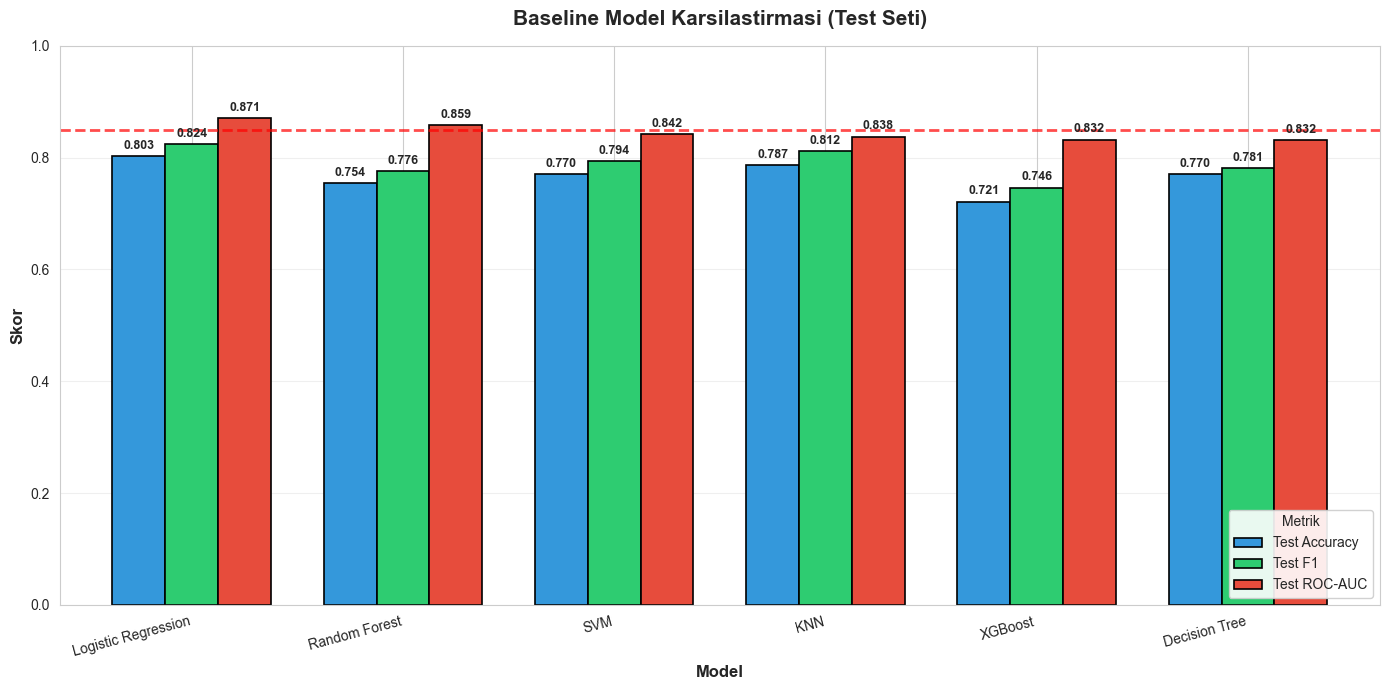


MODEL DEGERLENDIRMESI
En iyi:   Logistic Regression       (ROC-AUC: 0.8712)
En kotu:  Decision Tree             (ROC-AUC: 0.8317)
Fark:     0.0395

%85 hedefini gecen model sayisi: 0/6


In [27]:
# ============================================================
# 4. MODEL KARSILASTIRMA GORSELI
# ============================================================
# Her modelin Accuracy, F1 ve ROC-AUC degerlerini grafikte
# karsilastiralim. Bu grafik akademik raporun yildizi olacak.
# ============================================================

# Plot icin veri hazirla
metrics_to_plot = ['Test Accuracy', 'Test F1', 'Test ROC-AUC']
plot_df = results_df.set_index('Model')[metrics_to_plot]

# Renk paleti
colors = ['#3498db', '#2ecc71', '#e74c3c']

# Grafik
fig, ax = plt.subplots(figsize=(14, 7))
plot_df.plot(kind='bar', ax=ax, color=colors,
             edgecolor='black', linewidth=1.2, width=0.75)

ax.set_title('Baseline Model Karsilastirmasi (Test Seti)',
             fontsize=15, fontweight='bold', pad=15)
ax.set_xlabel('Model', fontsize=12, fontweight='bold')
ax.set_ylabel('Skor', fontsize=12, fontweight='bold')
ax.set_ylim(0.0, 1.0)
ax.set_xticklabels(plot_df.index, rotation=15, ha='right')
ax.legend(title='Metrik', loc='lower right', framealpha=0.9)
ax.axhline(y=0.85, color='red', linestyle='--', linewidth=2,
           alpha=0.7, label='Hedef: %85')
ax.grid(axis='y', alpha=0.3)

# Bar uzerine deger yaz
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', fontsize=9,
                 fontweight='bold', padding=3)

plt.tight_layout()

os.makedirs('../reports/figures', exist_ok=True)
plt.savefig('../reports/figures/08_model_comparison.png',
            dpi=150, bbox_inches='tight')
print("Grafik kaydedildi: reports/figures/08_model_comparison.png")

plt.show()

# Yorumlama
print("\n" + "=" * 60)
print("MODEL DEGERLENDIRMESI")
print("=" * 60)
best = results_df.iloc[0]
worst = results_df.iloc[-1]
print(f"En iyi:   {best['Model']:<25} (ROC-AUC: {best['Test ROC-AUC']:.4f})")
print(f"En kotu:  {worst['Model']:<25} (ROC-AUC: {worst['Test ROC-AUC']:.4f})")
print(f"Fark:     {best['Test ROC-AUC'] - worst['Test ROC-AUC']:.4f}")

models_above_85 = results_df[results_df['Test Accuracy'] >= 0.85]
print(f"\n%85 hedefini gecen model sayisi: {len(models_above_85)}/{len(results_df)}")
if len(models_above_85) > 0:
    print("Hedefi gecen modeller:")
    for _, row in models_above_85.iterrows():
        print(f"  - {row['Model']}: %{row['Test Accuracy']*100:.2f}")

En iyi 3 model: ['Logistic Regression', 'Random Forest', 'SVM']
Grafik kaydedildi: reports/figures/09_confusion_matrix.png


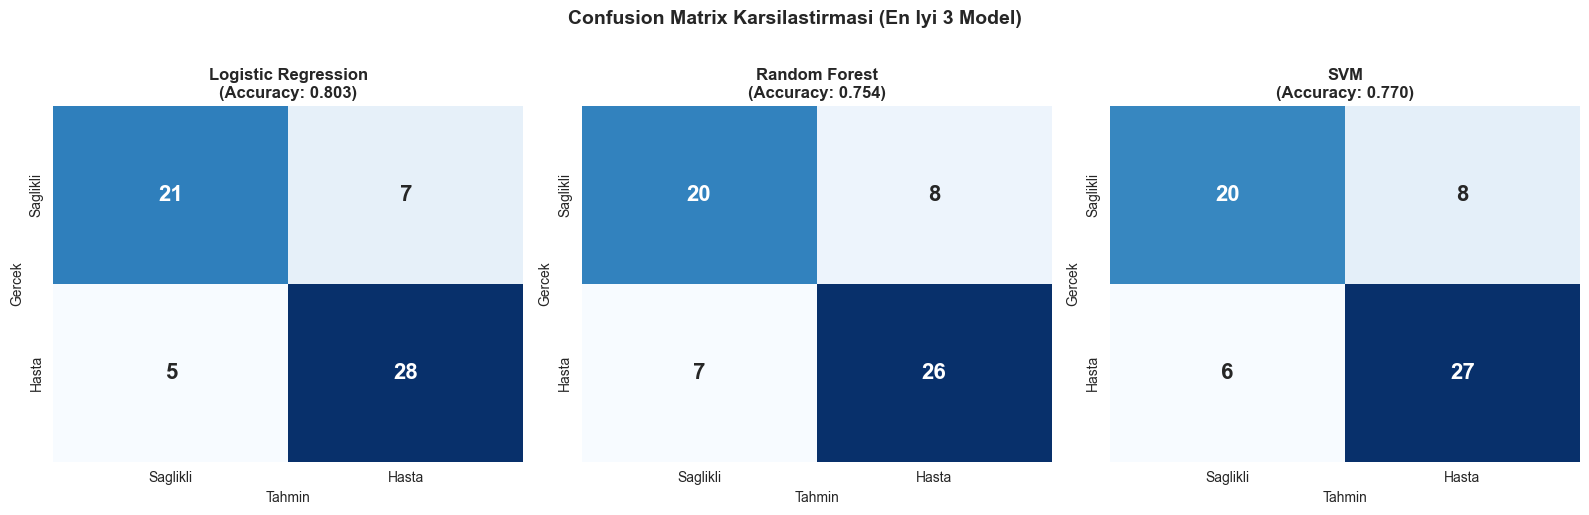

In [28]:
# ============================================================
# 5. CONFUSION MATRIX (En Iyi 3 Model)
# ============================================================

# En iyi 3 modeli al
top_3_models = results_df.head(3)['Model'].tolist()
print(f"En iyi 3 model: {top_3_models}")

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for idx, model_name in enumerate(top_3_models):
    # Modeli tekrar yukle (kaydetmistik)
    model_filename = model_name.lower().replace(' ', '_') + '.pkl'
    model = joblib.load(f'../models/trained/{model_filename}')
    
    # Tahmin yap
    y_pred = model.predict(X_test_scaled)
    
    # Confusion matrix hesapla
    cm = confusion_matrix(y_test, y_pred)
    
    # Heatmap olarak ciz
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Saglikli', 'Hasta'],
                yticklabels=['Saglikli', 'Hasta'],
                ax=axes[idx], cbar=False,
                annot_kws={'size': 16, 'fontweight': 'bold'})
    
    # Skor bilgisi
    acc = accuracy_score(y_test, y_pred)
    axes[idx].set_title(f'{model_name}\n(Accuracy: {acc:.3f})',
                        fontweight='bold')
    axes[idx].set_xlabel('Tahmin')
    axes[idx].set_ylabel('Gercek')

plt.suptitle('Confusion Matrix Karsilastirmasi (En Iyi 3 Model)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()

plt.savefig('../reports/figures/09_confusion_matrix.png',
            dpi=150, bbox_inches='tight')
print("Grafik kaydedildi: reports/figures/09_confusion_matrix.png")
plt.show()

Grafik kaydedildi: reports/figures/10_roc_curves.png


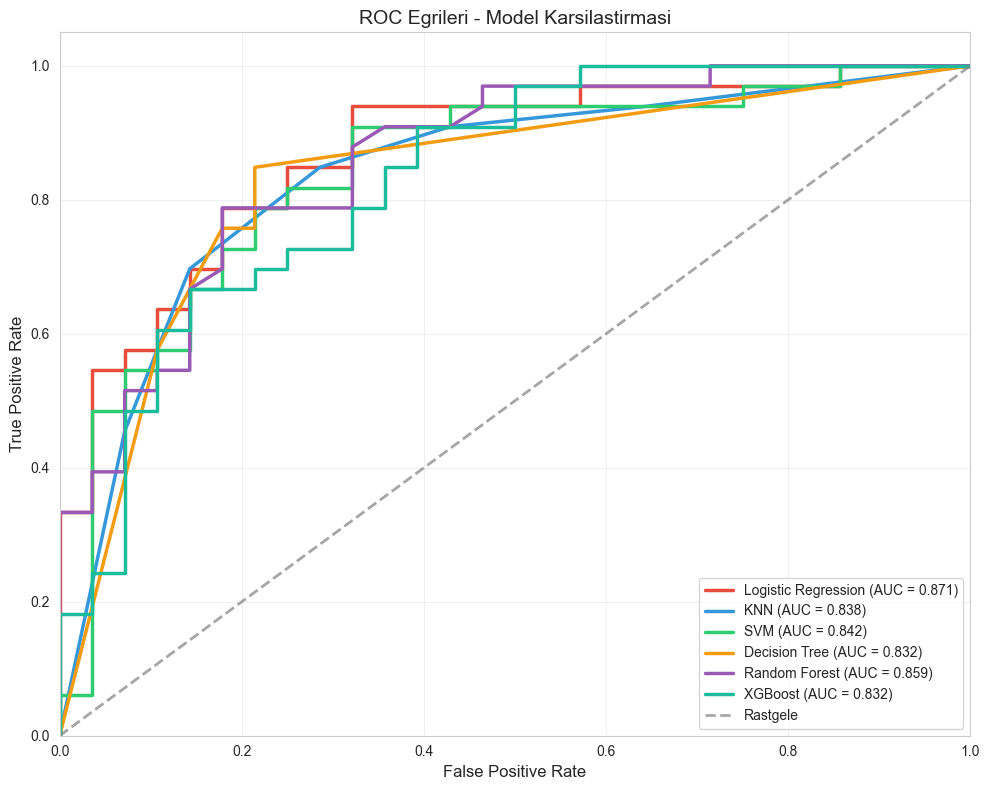


ROC-AUC OZETI:
  Logistic Regression: 0.8712
  Random Forest: 0.8588
  SVM: 0.8420
  KNN: 0.8377
  XGBoost: 0.8323
  Decision Tree: 0.8317


In [30]:
# ROC Egrileri - Tum Modeller
plt.figure(figsize=(10, 8))

colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12', '#9b59b6', '#1abc9c']

for idx, (name, model) in enumerate(models.items()):
    y_proba = model.predict_proba(X_test_scaled)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    plt.plot(fpr, tpr, color=colors[idx], linewidth=2.5, label=f'{name} (AUC = {auc:.3f})')

plt.plot([0, 1], [0, 1], color='gray', linestyle='--', linewidth=2, label='Rastgele', alpha=0.7)

plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Egrileri - Model Karsilastirmasi', fontsize=14)
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.xlim([0, 1])
plt.ylim([0, 1.05])
plt.tight_layout()

plt.savefig('../reports/figures/10_roc_curves.png', dpi=150, bbox_inches='tight')
print("Grafik kaydedildi: reports/figures/10_roc_curves.png")
plt.show()

print("\nROC-AUC OZETI:")
sorted_results = results_df.sort_values('Test ROC-AUC', ascending=False)
for _, row in sorted_results.iterrows():
    print(f"  {row['Model']}: {row['Test ROC-AUC']:.4f}")